# Production-Ready OCR & Document Understanding Mastery Challenge

# Step 3: Synthetc / Dummy Data Generation

---

# Overview

Research/Learn: Tools for synthetic document generation (Faker + ReportLab, synthtic ID generator, Photoshop/AI image tools).
Actions: Create blanced dummy dataset for each document types (img+pdf) with ground-truth label.
Milestone: Synthetic datasets (minximun 1000+ for each type) pushed to HF.

---



## Tools for synthetic data generation

- Faker: Python library is used to generate field data such as name, address, phone number, invoice number...
- ReportLab: Python library for generating PDFs and graphics.
- Augraphy: is a Python library that creates multiple copies of original documents though an augmentation pipeline that randomly distorts each copy. [Augraphy](https://augraphy.readthedocs.io/en/latest/)


### Generatio data using Faker

In [1]:
from faker import Faker
import json
fake = Faker()

results = []

for _ in range(3):
    entry = {
        "name": fake.name(),
        "job": fake.job(),
        "address": fake.address().replace('\n', ', '),
        "credit_card": fake.credit_card_number(card_type='visa')
    }
    results.append(entry)

print(json.dumps(results, indent=4))

[
    {
        "name": "Elizabeth Petty",
        "job": "Meteorologist",
        "address": "73585 Sherry Ramp Apt. 459, Andradeview, MP 79187",
        "credit_card": "4632445346345593"
    },
    {
        "name": "Peter Aguilar",
        "job": "Osteopath",
        "address": "1190 Jacob Passage, New Charleschester, VI 09553",
        "credit_card": "4643225280465756"
    },
    {
        "name": "Robert Stephens",
        "job": "Chief Strategy Officer",
        "address": "4883 Grace Cliffs Suite 492, Robbinsland, AL 25430",
        "credit_card": "4245754545968785"
    }
]


Generation PDF/Image with ReportLab.

### 

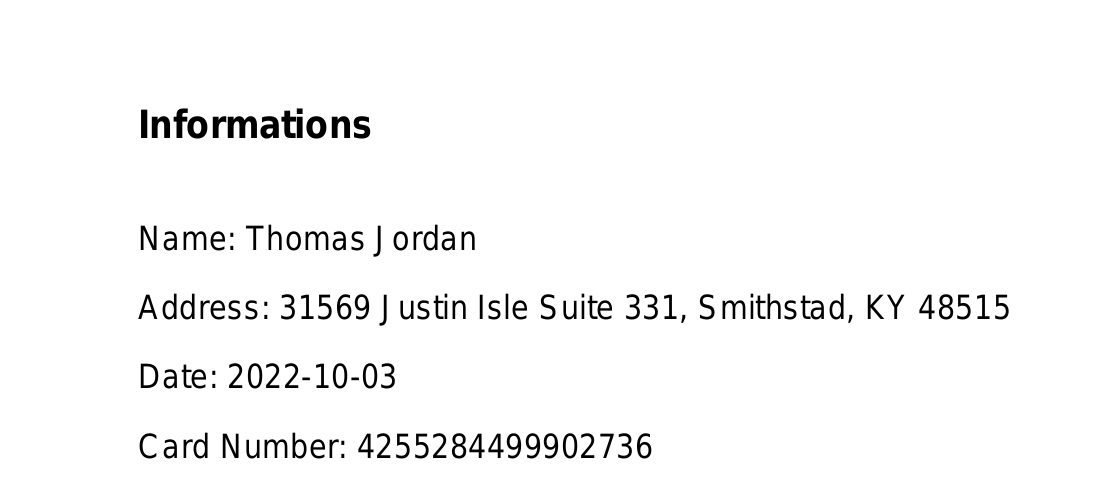

In [19]:

from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4
from io import BytesIO
from pdf2image import convert_from_bytes
from IPython.display import display

fake = Faker()
buffer = BytesIO()
c = canvas.Canvas(buffer, pagesize=(400, 180))
w, h = 400, 180

c.setFont("Helvetica-Bold", 14)
c.drawString(50, h - 50, "Informations")
c.setFont("Helvetica", 12)
lines = [
    f"Name: {fake.name()}",
    f"Address: {fake.address().replace(chr(10), ', ')}",
    f"Date: {fake.date()}",
    f"Card Number: {fake.credit_card_number(card_type='visa')}",
]

for i, line in enumerate(lines):
    c.drawString(50, h - 90 - i * 25, line)

c.save()

# convert PDF -> image
buffer.seek(0)
images = convert_from_bytes(buffer.read(), dpi=200)
# show 
display(images[0])

### Use Augrapphy to crate multiple copies of original documents


In [ ]:
# import sys
# !{sys.executable} -m pip install augraphy

In [ ]:
import augraphy
import numpy as np
from PIL import Image, ImageDraw
from math import ceil

img = Image.open("img/augraphy-example.png")
img_np = np.array(img.convert("RGB"))
augmenters = {
    "base":                None,
    "BadPhotoCopy":        augraphy.BadPhotoCopy(noise_iteration=(4,6), noise_size=(2,4), noise_sparsity=(0.6,0.9), noise_concentration=(0.4,0.8), blur_noise=1, edge_effect=1, p=1),
    "Faxify":              augraphy.Faxify(monochrome=1, halftone=1, invert=1, sigma=(2,4), p=1),
    "Folding":             augraphy.Folding(fold_count=5, fold_noise=0.1, gradient_width=(0.2,0.4), gradient_height=(0.02,0.05), p=1),
    "BleedThrough":        augraphy.BleedThrough(intensity_range=(0.7,0.95), color_range=(0,128), ksize=(31,31), alpha=0.6, p=1),
    "DirtyDrum":           augraphy.DirtyDrum(line_width_range=(3,8), line_concentration=0.5, noise_intensity=0.9, noise_value=(10,60), p=1),
    "InkBleed":            augraphy.InkBleed(intensity_range=(0.7,0.95), kernel_size=(7,7), severity=(0.5,0.7), p=1),
    "LowInkRandomLines":   augraphy.LowInkRandomLines(count_range=(20,40), noise_probability=0.5, p=1),
    "NoisyLines":          augraphy.NoisyLines(noisy_lines_direction=0, noisy_lines_number_range=(15,30), noisy_lines_thickness_range=(2,4), p=1),
    "InkMottling":         augraphy.InkMottling(ink_mottling_alpha_range=(0.7,0.9), ink_mottling_noise_scale_range=(3,5), ink_mottling_gaussian_kernel_range=(5,9), p=1),
    "DirtyRollers":        augraphy.DirtyRollers(line_width_range=(10,20), scanline_type=0, p=1),
    "BrightnessTexture":   augraphy.BrightnessTexturize(texturize_range=(0.5,0.75), deviation=0.2, p=1),
    "Gamma":               augraphy.Gamma(gamma_range=(0.2,0.45), p=1),
    "ShadowCast":          augraphy.ShadowCast(shadow_side="bottom", shadow_vertices_range=(2,6), shadow_width_range=(0.5,0.9), shadow_height_range=(0.4,0.7), shadow_opacity_range=(0.7,0.95), shadow_blur_kernel_range=(151,301), p=1),
    "SubtleNoise":         augraphy.SubtleNoise(subtle_range=80, p=1),
    "Scribbles":           augraphy.Scribbles(scribbles_type="random", scribbles_ink="pen", scribbles_location="random", scribbles_count_range=(3,8), scribbles_thickness_range=(2,4), p=1),
    "WaterMark":           augraphy.WaterMark(watermark_word="COPY", watermark_font_size=(20,30), watermark_font_thickness=(30,40), watermark_rotation=(30,60), watermark_method="darken", p=1),
    "BindingsAndFasteners": augraphy.BindingsAndFasteners(use_figshare_library=0, ntimes=(3,8), p=1),
    "BookBinding":          augraphy.BookBinding(curve_range_right=(80,150), curve_range_left=(250,350), enable_shadow=1, p=1),
    "Brightness":           augraphy.Brightness(brightness_range=(0.2,0.5), p=1),
    "ColorPaper":           augraphy.ColorPaper(hue_range=(28,45), saturation_range=(30,70), p=1),
    "ColorShift":           augraphy.ColorShift(color_shift_offset_x_range=(8,14), color_shift_offset_y_range=(8,14), color_shift_iterations=(3,5), p=1),
    "DelaunayTessellation": augraphy.DelaunayTessellation(n_points_range=(300,600), p=1),
    "DepthSimulatedBlur":   augraphy.DepthSimulatedBlur(blur_iteration_range=(10,14), p=1),
    "DirtyScreen":          augraphy.DirtyScreen(n_clusters=(80,150), n_samples=(5,25), p=1),
    "Dithering":            augraphy.Dithering(order=(3,6), p=1),
    "DotMatrix":            augraphy.DotMatrix(dot_matrix_dot_width_range=(5,15), dot_matrix_dot_height_range=(5,15), p=1),
    "DoubleExposure":       augraphy.DoubleExposure(offset_range=(25,40), p=1),
    "GlitchEffect":         augraphy.GlitchEffect(glitch_number_range=(10,20), glitch_size_range=(10,60), glitch_offset_range=(20,60), p=1),
    "Hollow":               augraphy.Hollow(p=1),
    "InkColorSwap":         augraphy.InkColorSwap(ink_swap_sequence_number_range=(8,15), p=1),
    "InkShifter":           augraphy.InkShifter(text_shift_scale_range=(20,35), text_shift_factor_range=(2,5), p=1),
    "Jpeg":                 augraphy.Jpeg(quality_range=(5,20), p=1),
    "LCDScreenPattern":     augraphy.LCDScreenPattern(pattern_overlay_alpha=0.6, p=1),
    "LensFlare":            augraphy.LensFlare(lens_flare_size=(2,6), p=1),
    "Letterpress":          augraphy.Letterpress(n_samples=(400,900), n_clusters=(400,900), p=1),
    "LightingGradient":     augraphy.LightingGradient(min_brightness=0, max_brightness=255, p=1),
    "LinesDegradation":     augraphy.LinesDegradation(line_split_probability=(0.4,0.6), line_replacement_probability=(0.5,0.7), p=1),
    "LowInkPeriodicLines":  augraphy.LowInkPeriodicLines(count_range=(5,10), period_range=(5,15), p=1),
    "LowLightNoise":        augraphy.LowLightNoise(num_photons_range=(10,30), p=1),
    "Markup":               augraphy.Markup(num_lines_range=(3,8), p=1),
    "Moire":                augraphy.Moire(moire_density=(10,18), moire_blend_alpha=0.4, p=1),
    "NoiseTexturize":       augraphy.NoiseTexturize(sigma_range=(5,15), turbulence_range=(3,6), p=1),
    "PageBorder":           augraphy.PageBorder(page_rotation_angle_range=(-5,5), p=1),
    "PatternGenerator":     augraphy.PatternGenerator(alpha_range=(0.4,0.7), p=1),
    "ReflectedLight":       augraphy.ReflectedLight(reflected_light_external_radius_range=(0.3,0.9), p=1),
    "SectionShift":         augraphy.SectionShift(section_shift_x_range=(-20,20), section_shift_number_range=(4,8), p=1),
    "Squish":               augraphy.Squish(squish_number_range=(8,14), squish_distance_range=(6,10), p=1),
    "Stains":               augraphy.Stains(stains_blend_alpha=0.7, p=1),
    "VoronoiTessellation":  augraphy.VoronoiTessellation(mult_range=(60,100), num_cells_range=(600,1200), p=1),
}

results = {}

for name, aug in augmenters.items():
    if aug is None:
        results[name] = img.convert("RGB")
    else:
        try:
            out = aug(img_np)

            # handle nhiều kiểu output
            if isinstance(out, dict):
                out = out.get("output", list(out.values())[0])

            if isinstance(out, Image.Image):
                img_out = out
            else:
                img_out = Image.fromarray(out)

            results[name] = img_out.convert("RGB")

        except Exception as e:
            print(f"SKIP {name}: {e}")

names = list(results.keys())
H, pad, label_h = 220, 10, 28
cols = 3
rows = ceil(len(names) / cols)

resized = {}
for n, im in results.items():
    ratio = H / im.height
    w = int(im.width * ratio)
    resized[n] = im.resize((w, H))

cell_w = max(im.width for im in resized.values())

grid = Image.new(
    "RGB",
    (cell_w * cols + pad * (cols + 1),
     (H + label_h + pad) * rows + pad),
    (240, 240, 240)
)

draw = ImageDraw.Draw(grid)

for idx, name in enumerate(names):
    row, col = divmod(idx, cols)

    x = pad + col * (cell_w + pad)
    y = pad + row * (H + label_h + pad)

    draw.rectangle([x, y, x + cell_w, y + label_h], fill=(40, 40, 40))
    label = f"[{idx+1:02d}] {name}"
    draw.text((x + 6, y + 6), label, fill=(255, 220, 80))
 

    im = resized[name]
    grid.paste(im, (x + (cell_w - im.width)//2, y + label_h))

display(grid)

SKIP BadPhotoCopy: 


In [30]:
# from PIL import Image

# img = Image.open("image.jpg")

(scale_range=(1.0, 1.25), monochrome=-1, monochrome_method='random', monochrome_arguments={}, halftone=-1, invert=1, half_kernel_size=(1, 1), angle=(0, 360), sigma=(1, 3), numba_jit=1, p=1)
